In [1]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

In [4]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

In [5]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [6]:
x_train /= 255
x_test /= 255

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

In [8]:
#https://keras.io/api/optimizers/
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 81s 41ms/step - loss: 0.2147 - accuracy: 0.9344
Epoch 2/10
1875/1875 [==============================] - 72s 38ms/step - loss: 0.0857 - accuracy: 0.9744
Epoch 3/10
1875/1875 [==============================] - 72s 38ms/step - loss: 0.0595 - accuracy: 0.9810
Epoch 4/10
1875/1875 [==============================] - 68s 36ms/step - loss: 0.0444 - accuracy: 0.9863
Epoch 5/10
1875/1875 [==============================] - 68s 36ms/step - loss: 0.0352 - accuracy: 0.9886
Epoch 6/10
1875/1875 [==============================] - 67s 36ms/step - loss: 0.0293 - accuracy: 0.9902
Epoch 7/10
1875/1875 [==============================] - 65s 35ms/step - loss: 0.0244 - accuracy: 0.9916
Epoch 8/10
1875/1875 [==============================] - 66s 35ms/step - loss: 0.0224 - accuracy: 0.9924
Epoch 9/10
1875/1875 [==============================] - 80s 43ms/step - loss: 0.0200 - accuracy: 0.9931
Epoch 10/10
1875/1875 [==============================] - 75s 40m

In [9]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 6s 10ms/step - loss: 0.0548 - accuracy: 0.9866


[0.0547575019299984, 0.9865999817848206]

In [11]:
y_pred = model.predict(x_test)

313/313 [==============================] - 3s 8ms/step


In [13]:
import numpy as np
y_pred_classes = np.argmax(y_pred, axis=1)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16876\2251650274.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


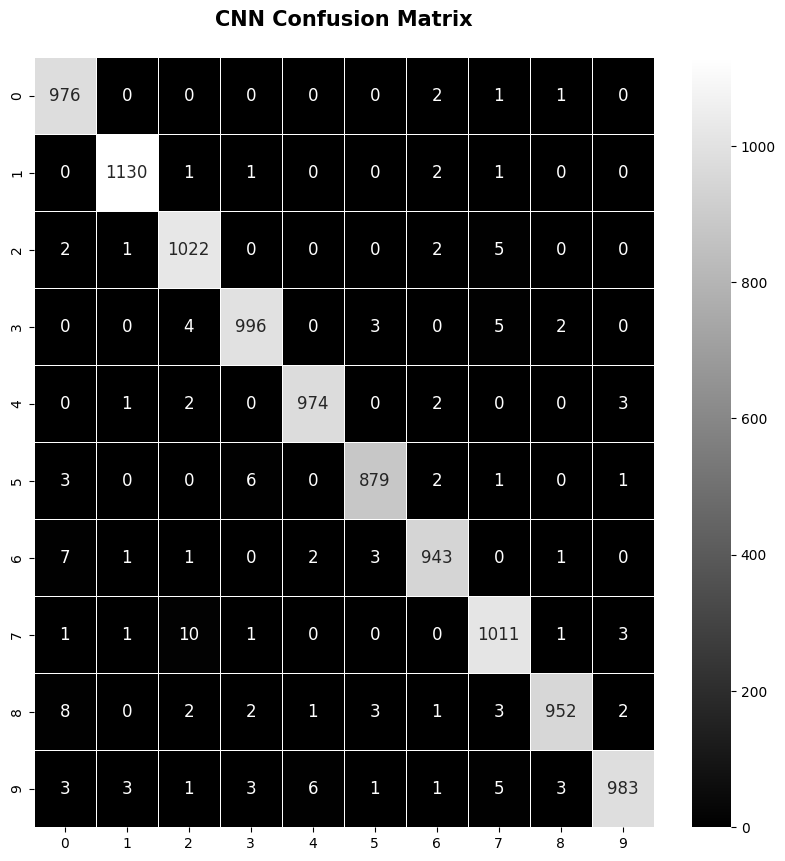

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Confusion matrix
con_mat=confusion_matrix(y_test,y_pred_classes)
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 12},linewidths=0.5,fmt="d",cmap="gray")
plt.title('CNN Confusion Matrix\n',fontweight='bold',fontsize=15)
plt.show()

1/1 [==============================] - 0s 325ms/step
6


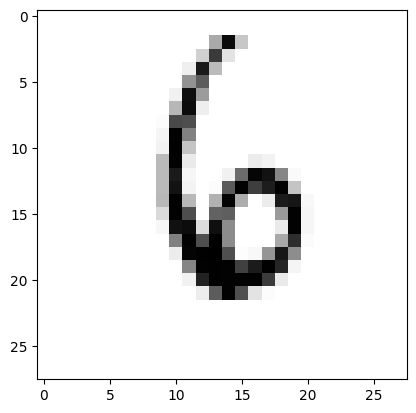

In [10]:
import matplotlib.pyplot as plt
image_index = 6900
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
predict = x_test[image_index].reshape(28,28)
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())